In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
# Load training, validation, and test datasets
train_df = pd.read_csv('/content/test.csv')
val_df = pd.read_csv('/content/validation.csv')
test_df = pd.read_csv('/content/test.csv')

# Combine datasets for preprocessing
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Display info
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nLabel Distribution:\n", df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    6000 non-null   object
 1   label   6000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 93.9+ KB
None

Missing values:
 text     0
label    0
dtype: int64

Label Distribution:
 label
1    2094
0    1712
3     825
4     660
2     496
5     213
Name: count, dtype: int64


In [4]:
nltk.download('punkt_tab')  # For preprocessing

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    stemmed = [stemmer.stem(t) for t in tokens]
    lemmatized = [lemmatizer.lemmatize(t) for t in stemmed]
    return ' '.join(lemmatized)

df['clean_text'] = df['text'].apply(preprocess)
df[['text', 'clean_text']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,clean_text
0,im feeling rather rotten so im not very ambiti...,im feel rather rotten im ambiti right
1,im updating my blog because i feel shitty,im updat blog feel shitti
2,i never make her separate from me because i do...,never make separ ever want feel like asham
3,i left with my bouquet of red and yellow tulip...,left bouquet red yellow tulip arm feel slightl...
4,i was feeling a little vain when i did this one,feel littl vain one


In [5]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Count Vectorizer
count_vec = CountVectorizer()
X_count = count_vec.fit_transform(df['clean_text'])

# Label encoding
y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [7]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train, y_train)

# Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

MultinomialNB()

Accuracy: 0.8183333333333334
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       334
           1       0.76      0.97      0.85       421
           2       0.94      0.36      0.52        92
           3       0.92      0.69      0.79       170
           4       0.94      0.71      0.80       143
           5       0.89      0.40      0.55        40

    accuracy                           0.82      1200
   macro avg       0.88      0.67      0.73      1200
weighted avg       0.84      0.82      0.81      1200



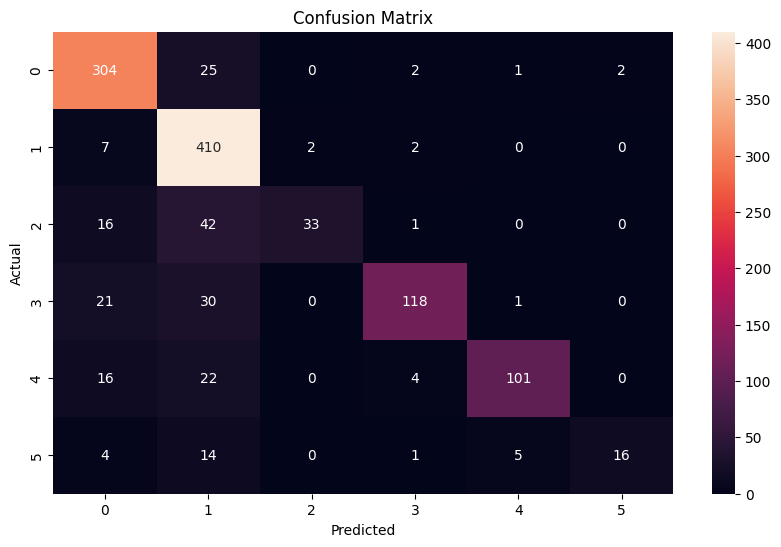

In [8]:
y_pred = model_lr.predict(X_test)  # or model_nb

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
new_text = ["i cant walk into a shop anywhere where i do not feel uncomfortable"]
new_text_clean = [preprocess(t) for t in new_text]
new_text_vec = tfidf.transform(new_text_clean)
predicted_label = model_lr.predict(new_text_vec)
print("Predicted Emotion:", predicted_label[0])

Predicted Emotion: 4


<ipython-input-10-0299292d52d0>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


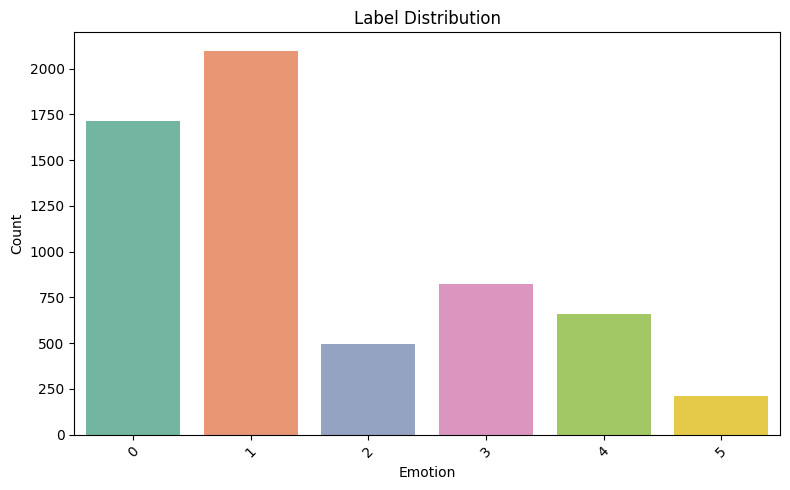

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-11-91f30b6d1b82>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='magma')


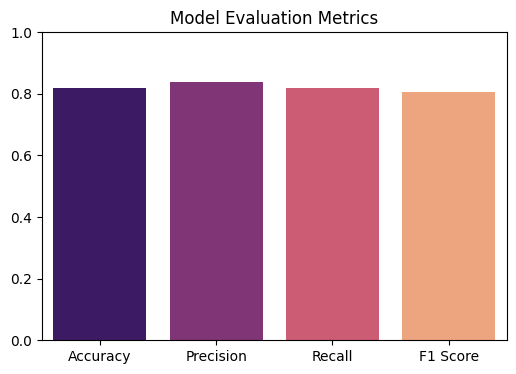

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted'),
    'Recall': recall_score(y_test, y_pred, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred, average='weighted')
}

plt.figure(figsize=(6, 4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='magma')
plt.title("Model Evaluation Metrics")
plt.ylim(0, 1)
plt.show()